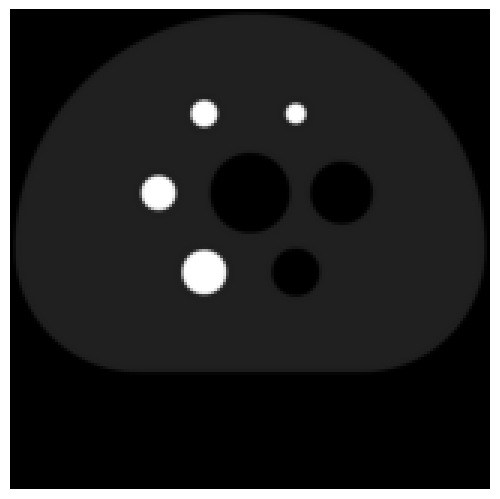

In [2]:
# ===================== Tạo phantom NEMA (NEMA NU1-2018) =====================
import numpy as np
import matplotlib.pyplot as plt
from skimage.transform import resize

# --------------------- Kích thước ---------------------
N = 160
size_mm = 300.0
res = 0.1
M = int(size_mm / res)

x = (np.arange(M) - M / 2) * res
y = (np.arange(M) - M / 2) * res
X, Y = np.meshgrid(x, y)

# --------------------- Mức hoạt độ chuẩn hóa ---------------------
background = 0.125
hot = 1.0
cold = 0.0
phantom = np.zeros((M, M), dtype=np.float32)
# ===================== Thân phantom =====================

R_lon = 147.0
R_duoi = 77.0
x_trai, x_phai = -70.0, 70.0
wall_body = 3.0

# Ba đường tròn tạo thành thân phantom
lon = X**2 + Y**2 <= R_lon**2
trai = (X + 70.0)**2 + Y**2 <= R_duoi**2
phai = (X - 70.0)**2 + Y**2 <= R_duoi**2

# Phần bên trong thân phantom
body_in = ((lon & (Y >= 0)) |(trai & (Y < 0)) |(phai & (Y < 0)))

# Nối phần đáy của hai đường tròn phía dưới
body_in |= ((X >= -70.0) &(X <= 70.0) &(Y >= -R_duoi) &(Y < 0))

# Thành thân phantom
lon_out = X**2 + Y**2 <= (R_lon + wall_body)**2
trai_out = (X + 70.0)**2 + Y**2 <= (R_duoi + wall_body)**2
phai_out = (X - 70.0)**2 + Y**2 <= (R_duoi + wall_body)**2

body_out = ((lon_out & (Y >= 0)) |(trai_out & (Y < 0)) |(phai_out & (Y < 0)))
body_out |= ((X >= -70.0 - wall_body) &(X <= 70.0 + wall_body) &(Y >= -R_duoi - wall_body) &(Y < 0))

phantom[body_in] = background
phantom[body_out & ~body_in] = cold

# ===================== Lõi (lung) =====================
lung_x, lung_y = 0.0, 35.0
lung_R = 25.0
lung = ((X - lung_x)**2 +(Y - lung_y)**2 <= lung_R**2)
phantom[lung] = cold

# ===================== Các lỗ tròn =====================
R_sphere = 57.2
wall_sphere = 1.0
spheres = [
    ("17 mm Hot",  17.0, 120.0, hot),
    ("13 mm Hot",  13.0,  60.0, hot),
    ("22 mm Hot",  22.0, 180.0, hot),
    ("37 mm Cold", 37.0,   0.0, cold),
    ("28 mm Hot",  28.0, 240.0, hot),
    ("28 mm Cold", 28.0, 300.0, cold)]

for name, diameter, angle, activity in spheres:
    a = np.deg2rad(angle)
    x0 = lung_x + R_sphere * np.cos(a)
    y0 = lung_y + R_sphere * np.sin(a)
    r = diameter / 2
    d2 = (X - x0)**2 + (Y - y0)**2

    # Thành lỗ tròn
    phantom[d2 <= (r + wall_sphere)**2] = cold

    # Phần bên trong lỗ tròn
    phantom[d2 <= r**2] = activity

# ===================== Resize về 160 × 160 pixel =====================
phantom = phantom[::-1, :]
nema_image = resize(phantom,(160, 160),order=1,mode="constant",cval=0,anti_aliasing=True,preserve_range=True)

# ===================== Hiển thị và lưu =====================
plt.figure(frameon=False)
plt.imshow(nema_image,cmap="gray",vmin=0,vmax=1,interpolation="nearest")
plt.axis("off")
plt.subplots_adjust(0, 0, 1, 1)
plt.show()
plt.imsave(r"C:\Users\thcsb\anaconda3\Lib\site-packages\skimage\data\phantomnema160.png",nema_image,cmap="gray",vmin=0,vmax=1)